# 1. Veri Hazırlığı ve Temizliği
## 1. Data Preparation & Cleaning

### 1.1. Kurulum ve Veri Yükleme
##### 1.1. Setup and Data Loading

In [1]:
# Gerekli kütüphanelerin içe aktarılması ve yapılandırma 
# Importing required libraries and configuration

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings

# Görünüm ve uyarı ayarları
# Display and warning settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Veriyi yükleme ve ilk bakış
# Data import and initial look

path = r"..\01_data\01_raw_data\DataCoSupplyChainDataset.csv"
df = pd.read_csv(path, encoding="ISO-8859-1")

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### 1.2. Sütun Standartlaştırma ve Filtreleme
##### 1.2. Column Standardization and Filtering

In [3]:
# Sütun isimlerinin standartlaştırılması (snake_case)
# Standardizing column names to snake_case

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '_', regex=True)
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'_+', '_', regex=True)
    .str.strip('_')
)

In [4]:
# Verinin yapısal analizi: Eksik değer, tekillik ve veri tiplerinin kontrolü
# Exploratory Data Analysis: Checking missing values, uniqueness, and data types

df_info = pd.DataFrame({
    'missing_values': df.isnull().sum(),
    'unique_values': df.nunique(),
    'dtype': df.dtypes
})

df_info.sort_values(by='missing_values', ascending=False)

,missing_values,unique_values,dtype
product_description,180519,0,float64
order_zipcode,155679,609,float64
customer_lname,8,1109,object
customer_zipcode,3,995,float64
days_for_shipment_scheduled,0,4,int64
sales_per_customer,0,2927,float64
benefit_per_order,0,21998,float64
delivery_status,0,4,object
late_delivery_risk,0,2,int64
customer_city,0,563,object


In [5]:
# Birbiriyle aynı olduğu (redundant) düşünülen sütun çiftlerinin tanımlanması
# Defining column pairs suspected of being identical

pairs = [
    ('order_item_cardprod_id', 'product_card_id'),
    ('product_category_id', 'category_id'),
    ('order_customer_id', 'customer_id'),
    ('order_profit_per_order', 'benefit_per_order'),
    ('order_item_total', 'sales_per_customer'),
    ('order_item_product_price', 'product_price'),
]

for col1, col2 in pairs:
    match = (df[col1] == df[col2]).all()
    print(f"{col1} == {col2} → {match}")

order_item_cardprod_id == product_card_id → True
product_category_id == category_id → True
order_customer_id == customer_id → True
order_profit_per_order == benefit_per_order → True
order_item_total == sales_per_customer → True
order_item_product_price == product_price → True


In [6]:
# Silinecek sütunların nedenlerine göre kategorize edilmesi
# Categorizing columns to be dropped based on removal criteria
cols_to_drop = [
    # Eksik veri veya bilgi taşımayanlar (High nulls or no information)
    'product_description',      # %100 null
    'order_zipcode',            # %86 null
    'product_status',           # Single unique value
    'product_image',            # Irrelevant content
    
    # Kişisel ve güvenlik verileri (PII & Security)
    'customer_password',
    'customer_email',
    'customer_street',
    
    # Kanıtlanmış mükerrer sütunlar (Proven redundant duplicates)
    'order_item_cardprod_id',   # == product_card_id
    'product_category_id',      # == category_id
    'order_customer_id',        # == customer_id
    'order_profit_per_order',   # == benefit_per_order
    'sales_per_customer',       # == order_item_total
    'order_item_product_price'  # == product_price
]

# Sütunların silinmesi ve sonuç çıktısı
# Dropping columns and printing the result
df.drop(columns=cols_to_drop, inplace=True)
print(f"Başlangıç: 53 sütun → Şimdi: {df.shape[1]} sütun")
print(f"Initial: 53 columns → Now: {df.shape[1]} columns")

Başlangıç: 53 sütun → Şimdi: 40 sütun
Initial: 53 columns → Now: 40 columns


In [7]:
# Müşteri isimlerinin birleştirilmesi ve orijinal sütunların silinmesi
#Merging customer names and dropping original columns

df['customer_name'] = (df['customer_fname'] + ' ' + df['customer_lname'].fillna('Unknown')).str.strip()
df.drop(columns=['customer_fname', 'customer_lname'], inplace=True)
print(df['customer_name'].head())

0       Cally Holloway
1           Irene Luna
2    Gillian Maldonado
3            Tana Tate
4       Orli Hendricks
Name: customer_name, dtype: object


In [8]:
# Eksik posta kodu değerlerinin 0 ile doldurulması
#Filling missing zipcode values with 0

df['customer_zipcode'] = df['customer_zipcode'].fillna(0)

In [9]:
# Güncel sütun listesinin görüntülenmesi
# Viewing the updated list of columns

print(df.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_date_dateorders', 'order_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_name', 'product_price', 'shipping_date_dateorders', 'shipping_mode', 'customer_name']


In [10]:
# Sütunların daha anlaşılır isimlerle yeniden adlandırılması
# Renaming columns for better clarity

df.rename(columns={
    'type'                          : 'payment_type',
    'late_delivery_risk'            : 'late_delivery',
    'days_for_shipment_scheduled'   : 'scheduled_days',
    'days_for_shipping_real'        : 'real_days',
    'order_date_dateorders'         : 'order_date',
    'shipping_date_dateorders'      : 'shipping_date',
    'order_item_discount'           : 'discount',
    'order_item_discount_rate'      : 'discount_rate',
    'order_item_profit_ratio'       : 'profit_ratio',
    'order_item_quantity'           : 'item_quantity',
    'order_item_id'                 : 'item_id',
    'product_card_id'               : 'product_id',
}, inplace=True)

print(df.columns.tolist())

['payment_type', 'real_days', 'scheduled_days', 'benefit_per_order', 'delivery_status', 'late_delivery', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_date', 'order_id', 'discount', 'discount_rate', 'item_id', 'profit_ratio', 'item_quantity', 'sales', 'order_item_total', 'order_region', 'order_state', 'order_status', 'product_id', 'product_name', 'product_price', 'shipping_date', 'shipping_mode', 'customer_name']


### 1.3. Veri Tutarlılığı ve Kategori Analizi
#### 1.3. Data Integrity and Category Analysis

In [11]:
# Kategori isimleri ve ID'leri arasındaki tutarsızlığın (1:1 ilişki) incelenmesi
# Investigating inconsistencies between category names and IDs

df.groupby('category_name')['category_id'].nunique().sort_values(ascending=False).head()

category_name
Electronics        2
Accessories        1
As Seen on  TV!    1
Baby               1
Basketball         1
Name: category_id, dtype: int64

In [12]:
# "Electronics" kategorisindeki ID tutarsızlığının detaylı incelenmesi
# Detailed investigation of ID inconsistency in the "Electronics" category

df[df['category_name'] == 'Electronics'][['category_id', 'category_name']].drop_duplicates()

,category_id,category_name
55,13,Electronics
62,37,Electronics


In [13]:
# "Electronics" kategorisindeki tutarsızlığın kaynağını anlamak için departman ve ürün detaylarının incelenmesi
# Investigating department and product details to understand the source of inconsistency in the "Electronics" category

df[df['category_name'] == 'Electronics'][['category_id', 'department_name', 'product_name']].drop_duplicates().sort_values('category_id')

,category_id,department_name,product_name
55,13,Footwear,Under Armour Men's Compression EV SL Slide
303,13,Footwear,Under Armour Kids' Mercenary Slide
308,13,Footwear,Under Armour Women's Ignite PIP VI Slide
482,13,Footwear,Under Armour Women's Ignite Slide
116,37,Outdoors,Bridgestone e6 Straight Distance NFL Tennesse
115,37,Outdoors,Titleist Pro V1x Golf Balls
361,37,Outdoors,Titleist Pro V1x High Numbers Golf Balls
62,37,Outdoors,Bridgestone e6 Straight Distance NFL San Dieg
480,37,Outdoors,Bridgestone e6 Straight Distance NFL Carolina
505,37,Outdoors,Titleist Pro V1x High Numbers Personalized Go


In [14]:
# Kategori isimlerindeki tutarsızlıkların giderilmesi ve kontrolü
# Resolving category name inconsistencies and verification

# ID 13 artık "Footwear" (veya "Sandal/Slide")
df.loc[df['category_id'] == 13, 'category_name'] = 'Mens/Womens Footwear'

# ID 37 artık "Golf Accessories" (Çünkü hepsi golf topu)
df.loc[df['category_id'] == 37, 'category_name'] = 'Golf Accessories'

print(df['category_name'].nunique())
print(df['category_id'].nunique())

51
51


### 1.4. Formatlama ve Tip Dönüşümleri
##### 1.4. Formatting and Type Conversions

In [15]:
# Tarih sütunlarının 'datetime' formatına dönüştürülmesi
# Converting date columns to 'datetime' format

df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])

df[['order_date', 'shipping_date']].dtypes

order_date       datetime64[ns]
shipping_date    datetime64[ns]
dtype: object

In [16]:
# Metin sütunlarındaki boşlukların temizlenmesi ve standardizasyonu
# Cleaning and standardizing whitespace in string columns

# Temizlenecek tüm sütunlar (object + category)
str_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
# Doğrulayalım
df[str_cols].head()

,payment_type,delivery_status,category_name,customer_city,customer_country,customer_segment,customer_state,department_name,market,order_city,order_country,order_region,order_state,order_status,product_name,shipping_mode,customer_name
0,DEBIT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,Pacific Asia,Bekasi,Indonesia,Southeast Asia,Java Occidental,COMPLETE,Smart watch,Standard Class,Cally Holloway
1,TRANSFER,Late delivery,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,Pacific Asia,Bikaner,India,South Asia,Rajastán,PENDING,Smart watch,Standard Class,Irene Luna
2,CASH,Shipping on time,Sporting Goods,San Jose,EE. UU.,Consumer,CA,Fitness,Pacific Asia,Bikaner,India,South Asia,Rajastán,CLOSED,Smart watch,Standard Class,Gillian Maldonado
3,DEBIT,Advance shipping,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,Fitness,Pacific Asia,Townsville,Australia,Oceania,Queensland,COMPLETE,Smart watch,Standard Class,Tana Tate
4,PAYMENT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,Fitness,Pacific Asia,Townsville,Australia,Oceania,Queensland,PENDING_PAYMENT,Smart watch,Standard Class,Orli Hendricks


### 1.5. Eksik Veri ve Anomali Yönetimi
#### 1.5. Missing Data and Anomaly Management

In [17]:
# Eksik değer içeren sütunların ve toplam eksik sayılarının incelenmesi
# Investigating columns with missing values and their total counts

df[df.isnull().any(axis=1)].isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [18]:
# Kategorik sütunlardaki nadir değerlerin, yazım hatalarının ve anomalilerin tespiti
# Identification of rare values, spelling errors, and anomalies in categorical columns

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().tail(5))


payment_type:
payment_type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

delivery_status:
delivery_status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

category_name:
category_name
Soccer               138
Strength Training    111
As Seen on TV!        68
Basketball            67
Golf Bags & Carts     61
Name: count, dtype: int64

customer_city:
customer_city
Bartlett    25
Ponce       22
Malden      22
Freehold    13
CA           3
Name: count, dtype: int64

customer_country:
customer_country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

customer_segment:
customer_segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

customer_state:
customer_state
MT       87
IA       67
AL       35
95758     2
91732     1
Name: count, dtype: int64

department_name:
department_name
Discs Shop 

In [19]:
# Tespit edilen lokasyon bazlı anomalilerin detaylı incelenmesi
# Detailed investigation of detected location-based anomalies

print(df[df['customer_city'] == 'CA'][['customer_city', 'customer_state', 'customer_country']])
print(df[df['customer_state'].isin(['95758', '91732'])][['customer_city', 'customer_state', 'customer_country']])

      customer_city customer_state customer_country
35704            CA          95758          EE. UU.
46440            CA          95758          EE. UU.
82511            CA          91732          EE. UU.
      customer_city customer_state customer_country
35704            CA          95758          EE. UU.
46440            CA          95758          EE. UU.
82511            CA          91732          EE. UU.


In [20]:
# Lokasyon anomalilerinin silinmesi ve indeksin sıfırlanması
# Removing location anomalies and resetting the index

df = df[~df['customer_state'].isin(['95758', '91732'])].reset_index(drop=True)

print(f"Kalan satır sayısı: {df.shape[0]}")
print(f"Remaining number of rows: {df.shape[0]}")

Kalan satır sayısı: 180516
Remaining number of rows: 180516


### 1.6. Bellek Optimizasyonu ve İstatistiksel Özet
#### 1.6. Memory Optimization and Statistical Summary

In [21]:
# Bellek optimizasyonu için düşük kardinaliteli sütunların 'category' tipine dönüştürülmesi
# Converting low-cardinality columns to 'category' type for memory optimization

cat_cols = [
    'customer_country', 'customer_segment', 'payment_type',
    'delivery_status', 'shipping_mode', 'market', 'order_status',
    'department_name', 'order_region', 'customer_state',
    'category_name', 'order_country', 'product_name'
]

df[cat_cols] = df[cat_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180516 entries, 0 to 180515
Data columns (total 39 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   payment_type       180516 non-null  category      
 1   real_days          180516 non-null  int64         
 2   scheduled_days     180516 non-null  int64         
 3   benefit_per_order  180516 non-null  float64       
 4   delivery_status    180516 non-null  category      
 5   late_delivery      180516 non-null  int64         
 6   category_id        180516 non-null  int64         
 7   category_name      180516 non-null  category      
 8   customer_city      180516 non-null  object        
 9   customer_country   180516 non-null  category      
 10  customer_id        180516 non-null  int64         
 11  customer_segment   180516 non-null  category      
 12  customer_state     180516 non-null  category      
 13  customer_zipcode   180516 non-null  float64 

In [22]:
# Sayısal değişkenlerin istatistiksel özeti ve dağılım analizi
# Statistical summary and distribution analysis of numerical variables

df.describe().T

,count,mean,min,25%,50%,75%,max,std
real_days,180516.0,3.497657,0.0,2.0,3.0,5.0,6.0,1.623731
scheduled_days,180516.0,2.931845,0.0,2.0,4.0,4.0,4.0,1.374449
benefit_per_order,180516.0,21.974593,-4274.97998,7.0,31.52,64.800003,911.799988,104.4343
late_delivery,180516.0,0.548295,0.0,0.0,1.0,1.0,1.0,0.497664
category_id,180516.0,31.850855,2.0,18.0,29.0,45.0,76.0,15.639498
customer_id,180516.0,6691.237015,1.0,3258.0,6456.5,9779.0,20757.0,4162.802258
customer_zipcode,180516.0,35921.126914,603.0,725.0,19380.0,78207.0,99205.0,37542.461122
department_id,180516.0,5.443423,2.0,4.0,5.0,7.0,12.0,1.629199
latitude,180516.0,29.71983,-33.937553,18.265432,33.144863,39.279617,48.781933,9.813676
longitude,180516.0,-84.915074,-158.025986,-98.446312,-76.840759,-66.370583,115.263077,21.432911


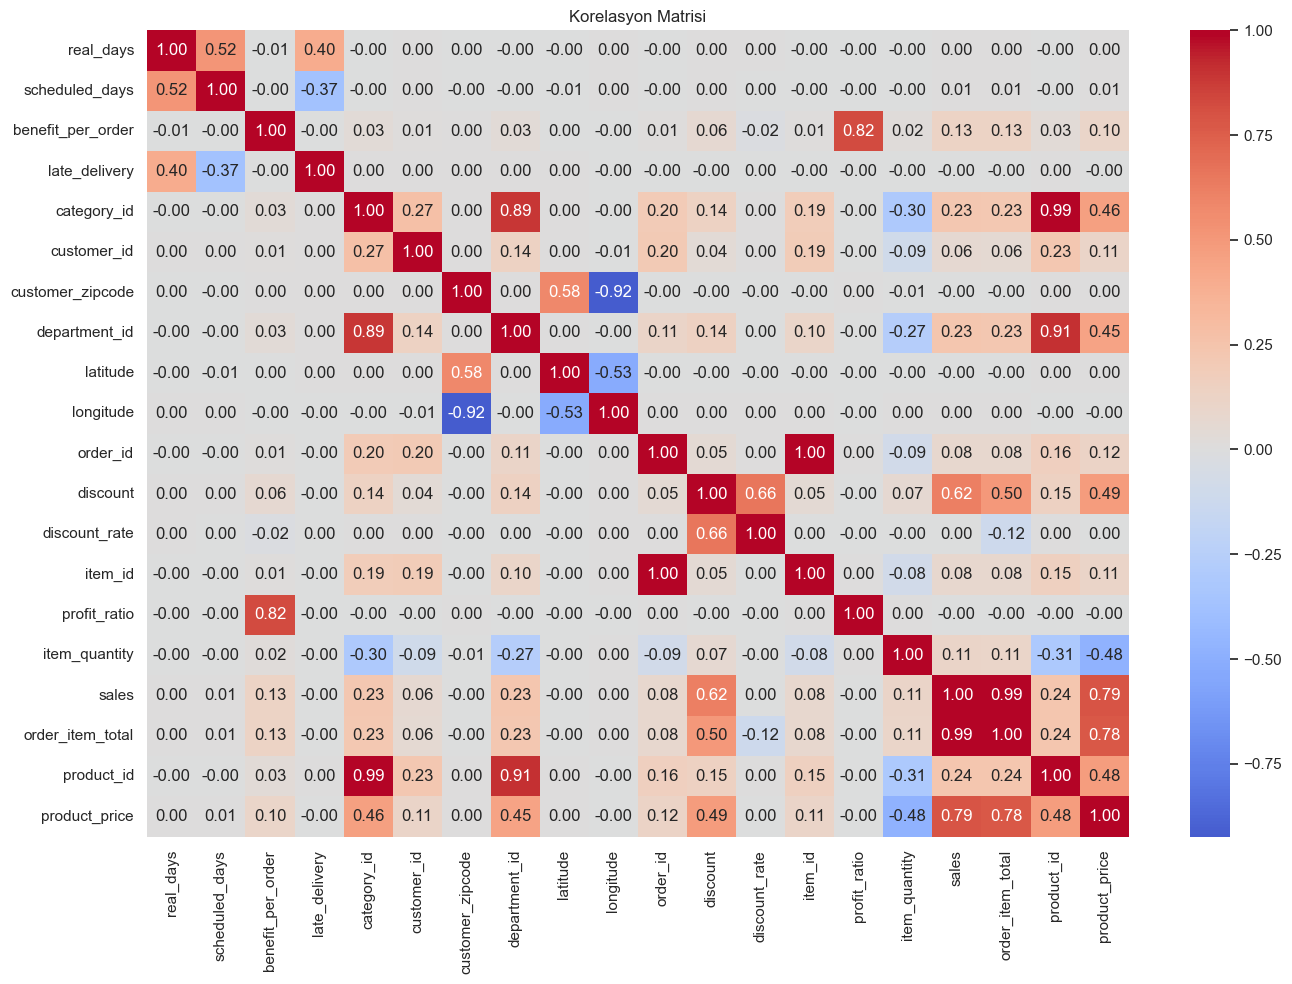

In [23]:
# Sayısal değişkenler arasındaki ilişkilerin (korelasyon) görselleştirilmesi
# Visualizing relationships (correlation) between numerical variables

corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

### 1.7. Özellik Mühendisliği
#### 1.7. Feature Engineering

In [24]:
# Tarih verisinden yeni zamansal değişkenlerin türetilmesi
# Deriving new temporal variables from date data

df['order_day_of_week'] = df['order_date'].dt.dayofweek # 0=Pazartesi, 6=Pazar
df['order_month'] = df['order_date'].dt.month
df['order_hour'] = df['order_date'].dt.hour
df['is_weekend'] = (df['order_day_of_week'] >= 5).astype(int)

In [25]:
# Yeni türetilen zamansal özelliklerin doğruluğunun kontrol edilmesi
# Verifying the accuracy of newly derived temporal features

df[['order_date', 'order_day_of_week', 'order_month', 'order_hour', 'is_weekend']].head()

,order_date,order_day_of_week,order_month,order_hour,is_weekend
0,2018-01-31 22:56:00,2,1,22,0
1,2018-01-13 12:27:00,5,1,12,1
2,2018-01-13 12:06:00,5,1,12,1
3,2018-01-13 11:45:00,5,1,11,1
4,2018-01-13 11:24:00,5,1,11,1


### 1.8. Temizlenmiş Veriyi Dışa Aktarma
#### 1.8. Exporting Cleaned Data

In [26]:
# Temizlenmiş veri setinin CSV formatında dışa aktarılması
# Exporting the cleaned dataset to CSV format

output_path = r"..\01_data\02_processed_data\supply_chain_refined_data.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Kaydedildi: {df.shape[0]} satır, {df.shape[1]} sütun / Saved: {df.shape[0]} rows, {df.shape[1]} columns")

Kaydedildi: 180516 satır, 43 sütun / Saved: 180516 rows, 43 columns


# 2. Keşifçi Veri Analizi ve Görselleştirme
## 2. Exploratory Data Analysis & Visualization

### 2.1. Görselleştirme
##### 2.1. Visualizations

In [27]:
# Marka renk paleti tanımlamaları ve görselleştirme ayarları
# Brand color palette definitions and visualization settings

PRIMARY = '#2C3E50'
SECONDARY = '#2980B9'
ACCENT = '#E74C3C'
LIGHT = '#BDC3C7'

sns.set_theme(style='white')
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12

### 2.2. Genel Bakış
##### 2.2. Overview

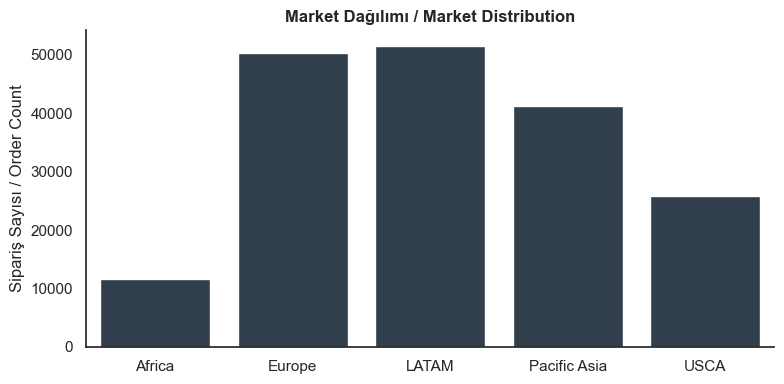

In [28]:
plt.figure(figsize=(8, 4))
market_counts = df['market'].value_counts()
sns.barplot(x=market_counts.index, y=market_counts.values, color=PRIMARY)
plt.title('Market Dağılımı / Market Distribution')
plt.xlabel('')
plt.ylabel('Sipariş Sayısı / Order Count')
sns.despine()
plt.tight_layout()
plt.show()

> LATAM ve Europe en yüksek sipariş hacmine sahip pazarlar olup birbirine oldukça yakın seyrediyor. 
> Africa pazarı diğerlerine kıyasla belirgin şekilde düşük hacimde kalıyor.

> LATAM and Europe lead in order volume with very similar figures. 
> Africa significantly lags behind the other markets.

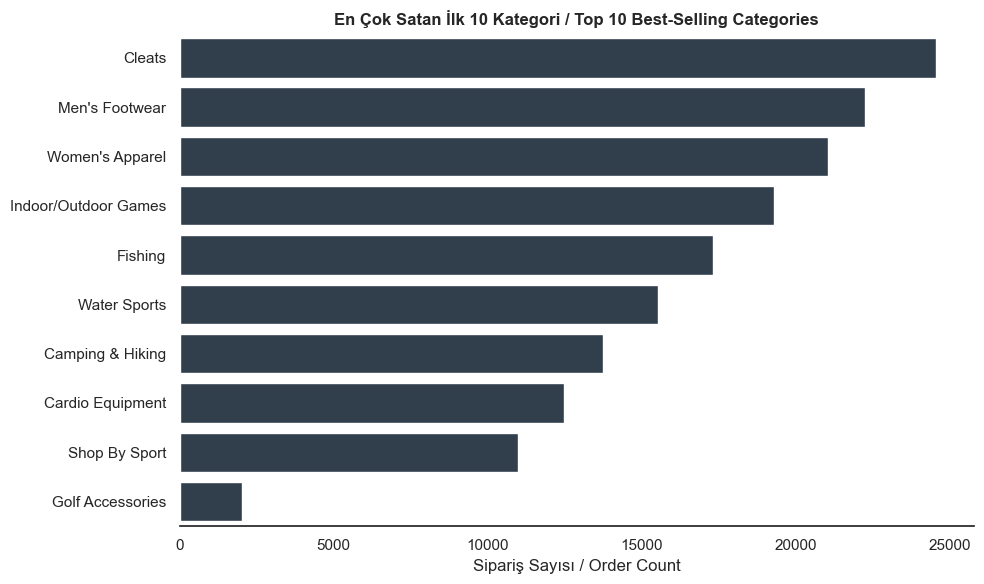

In [29]:
plt.figure(figsize=(10, 6))
top_cat = df['category_name'].value_counts().nlargest(10)
sns.barplot(x=top_cat.values, y=top_cat.index.astype(str), color=PRIMARY)
plt.title('En Çok Satan İlk 10 Kategori / Top 10 Best-Selling Categories')
plt.xlabel('Sipariş Sayısı / Order Count')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> Cleats, Men's Footwear ve Women's Apparel ilk üç sırayı alıyor; spor ve outdoor kategorileri genel olarak 
> listenin büyük bölümünü oluşturuyor. Golf Accessories ise ilk 10'a girmiş olmasına rağmen diğerlerinden 
> belirgin şekilde ayrışıyor.

> Cleats, Men's Footwear, and Women's Apparel lead the top three; sports and outdoor categories dominate 
> the list overall. Golf Accessories, despite making the top 10, stands out with a significantly lower count.

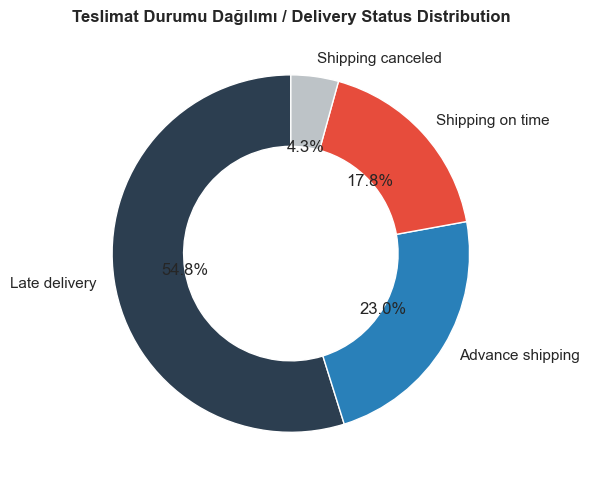

In [30]:
counts = df['delivery_status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
        colors=[PRIMARY, SECONDARY, ACCENT, LIGHT], wedgeprops={'width': 0.4})
plt.title('Teslimat Durumu Dağılımı / Delivery Status Distribution')
plt.tight_layout()
plt.show()

> Siparişlerin %54.8'i gecikmeli teslim ediliyor; bu oran ciddi bir operasyonel sorun işareti.
> Advance shipping (%23) ve Shipping on time (%17.8) birlikte değerlendirildiğinde siparişlerin 
> yalnızca %40.8'i zamanında veya erken teslim ediliyor.

> 54.8% of orders are delivered late, indicating a serious operational issue.
> When Advance shipping (23%) and Shipping on time (17.8%) are combined, only 40.8% of orders 
> are delivered on time or early.

### 2.3. Zaman Analizi
##### 2.3. Time Analysis

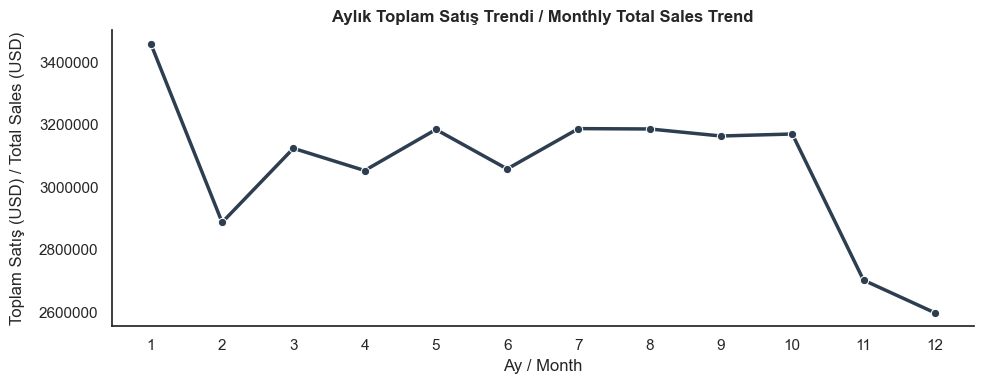

In [31]:
plt.figure(figsize=(10, 4))
monthly_sales = df.groupby('order_month')['sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color=PRIMARY, linewidth=2.5)
plt.title('Aylık Toplam Satış Trendi / Monthly Total Sales Trend')
plt.xlabel('Ay / Month')
plt.ylabel('Toplam Satış (USD) / Total Sales (USD)', labelpad=10)
plt.xticks(range(1, 13))
plt.ticklabel_format(style='plain', axis='y')
sns.despine()
plt.tight_layout()
plt.show()

> Ocak ayında zirveye ulaşan satışlar yıl içinde dalgalı bir seyir izliyor. Yılın son çeyreğinde 
> (Kasım-Aralık) belirgin bir düşüş göze çarpıyor.

> Sales peak in January and follow a fluctuating trend throughout the year. A notable decline 
> in the last quarter (November-December) is visible.

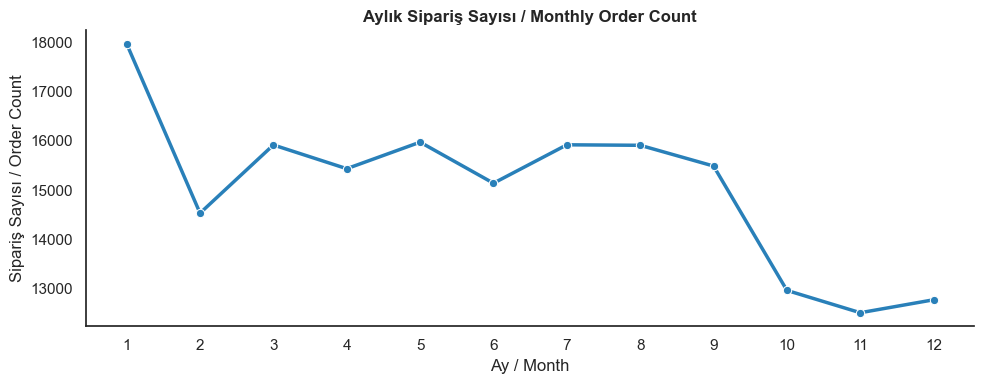

In [32]:
plt.figure(figsize=(10, 4))
monthly_orders = df.groupby('order_month')['order_id'].count()
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, marker='o', color=SECONDARY, linewidth=2.5)
plt.title('Aylık Sipariş Sayısı / Monthly Order Count')
plt.xlabel('Ay / Month')
plt.ylabel('Sipariş Sayısı / Order Count')
plt.xticks(range(1, 13))
sns.despine()
plt.tight_layout()
plt.show()

> Sipariş sayısı trendi toplam satış trendiyle paralel seyrediyor; Ocak zirvesi ve yıl sonu düşüşü 
> burada da görülüyor. Bu iki grafiğin benzer pattern göstermesi, satış düşüşünün fiyat değil 
> sipariş adedi kaynaklı olduğuna işaret ediyor.

> Order count trend mirrors the total sales trend, with a January peak and a year-end decline. 
> The similar pattern across both charts suggests the revenue drop is driven by order volume 
> rather than pricing changes.

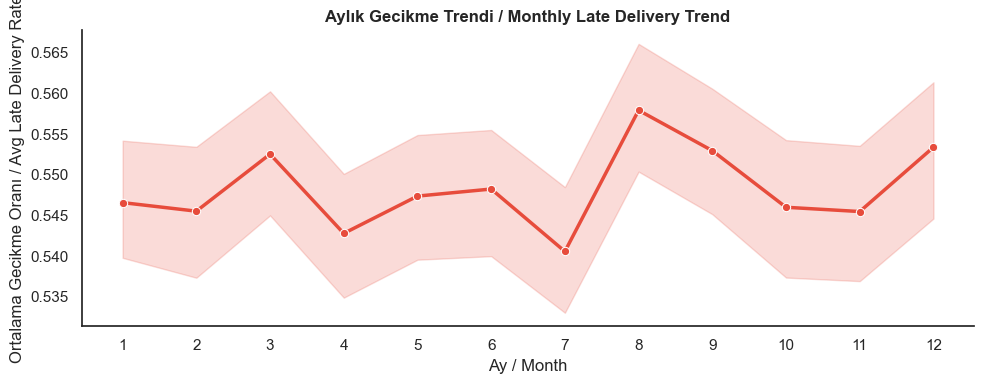

In [33]:
plt.figure(figsize=(10, 4))
sns.lineplot(x='order_month', y='late_delivery', data=df, marker='o', color=ACCENT, linewidth=2.5)
plt.title('Aylık Gecikme Trendi / Monthly Late Delivery Trend')
plt.xlabel('Ay / Month')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.xticks(range(1, 13))
sns.despine()
plt.tight_layout()
plt.show()

> Gecikme oranı tüm yıl boyunca %54-57 bandında seyrediyor; belirgin bir mevsimsellik veya 
> iyileşme trendi gözlemlenmiyor. Bu durum gecikmenin yapısal bir sorun olduğuna işaret ediyor.

> The late delivery rate hovers between 54-57% throughout the year with no clear seasonality 
> or improvement trend. This suggests that late delivery is a structural issue rather than 
> a seasonal one.

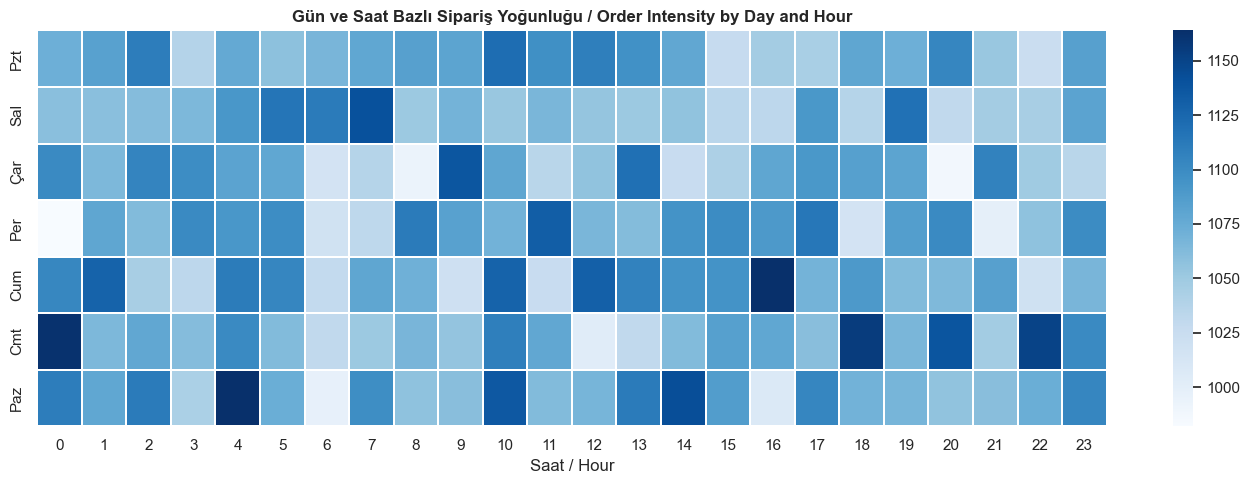

In [34]:
pivot = df.pivot_table(index='order_day_of_week', columns='order_hour', values='order_id', aggfunc='count')
pivot.index = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='Blues', annot=False, linewidths=0.3)
plt.title('Gün ve Saat Bazlı Sipariş Yoğunluğu / Order Intensity by Day and Hour')
plt.xlabel('Saat / Hour')
plt.ylabel('')
plt.tight_layout()
plt.show()

> Sipariş yoğunluğu gün ve saat bazında oldukça homojen bir dağılım gösteriyor; belirgin bir 
> zirve saati veya gün tespit edilemiyor. Bu durum siparişlerin 7/24 düzenli bir şekilde 
> geldiğine işaret ediyor.

> Order intensity appears fairly uniform across days and hours with no clear peak time or day. 
> This suggests orders are placed consistently around the clock throughout the week.

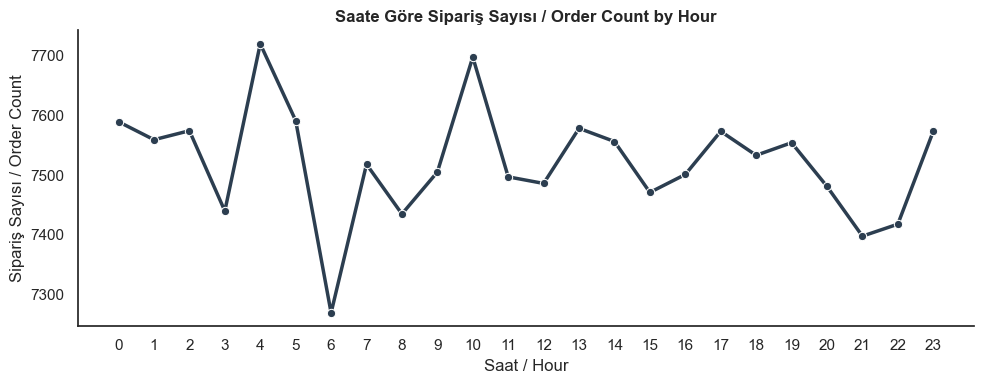

In [35]:
plt.figure(figsize=(10, 4))
hourly_orders = df.groupby('order_hour')['order_id'].count()
sns.lineplot(x=hourly_orders.index, y=hourly_orders.values, marker='o', color=PRIMARY, linewidth=2.5)
plt.title('Saate Göre Sipariş Sayısı / Order Count by Hour')
plt.xlabel('Saat / Hour')
plt.ylabel('Sipariş Sayısı / Order Count')
plt.xticks(range(0, 24))
sns.despine()
plt.tight_layout()
plt.show()

> Saat 04 ve 10'da belirgin zirveler göze çarpıyor; saat 06'da ise dikkat çekici bir düşüş var. 
> Genel olarak sipariş sayısı 7300-7700 bandında dar bir aralıkta seyrediyor, 
> yani belirgin bir "prime time" yok.

> Notable peaks appear at 04:00 and 10:00, with a dip at 06:00. 
> Overall, order counts stay within a narrow 7300-7700 range, 
> suggesting no single dominant ordering hour.

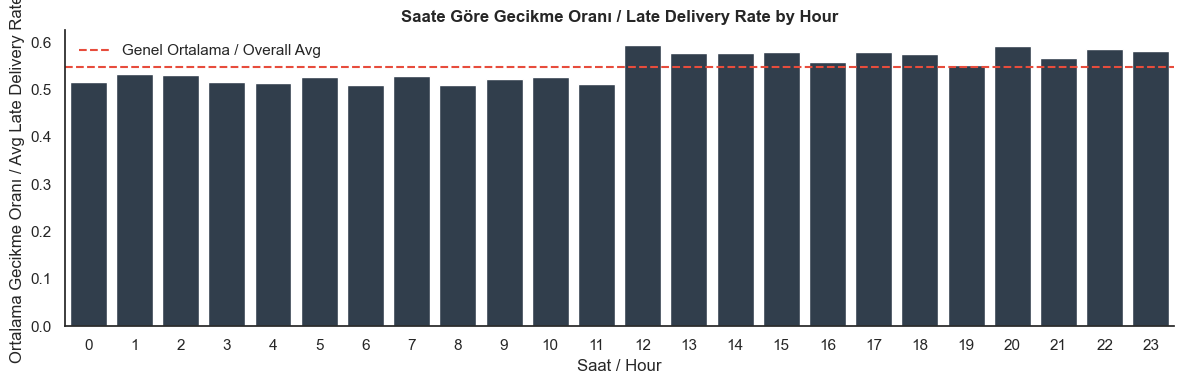

In [36]:
plt.figure(figsize=(12, 4))
sns.barplot(x='order_hour', y='late_delivery', data=df, color=PRIMARY, errorbar=None)
plt.axhline(df['late_delivery'].mean(), color=ACCENT, linestyle='--', label='Genel Ortalama / Overall Avg')
plt.title('Saate Göre Gecikme Oranı / Late Delivery Rate by Hour')
plt.xlabel('Saat / Hour')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

> Öğleden sonra (12-16) verilen siparişlerde gecikme oranı genel ortalamanın belirgin şekilde 
> üzerine çıkıyor. Sabah saatlerinde (0-11) ise ortalama altında kalıyor. Sipariş saati 
> gecikme tahmininde potansiyel bir özellik olabilir.

> Orders placed in the afternoon (12-16) show a notably higher late delivery rate than the 
> overall average. Morning hours (0-11) tend to stay below average. Order hour may serve 
> as a useful feature for predicting late deliveries.

### 2.4. Teslimat & Gecikme Analizi
##### 2.4. Delivery & Late Delivery Analysis

<Figure size 1000x500 with 0 Axes>

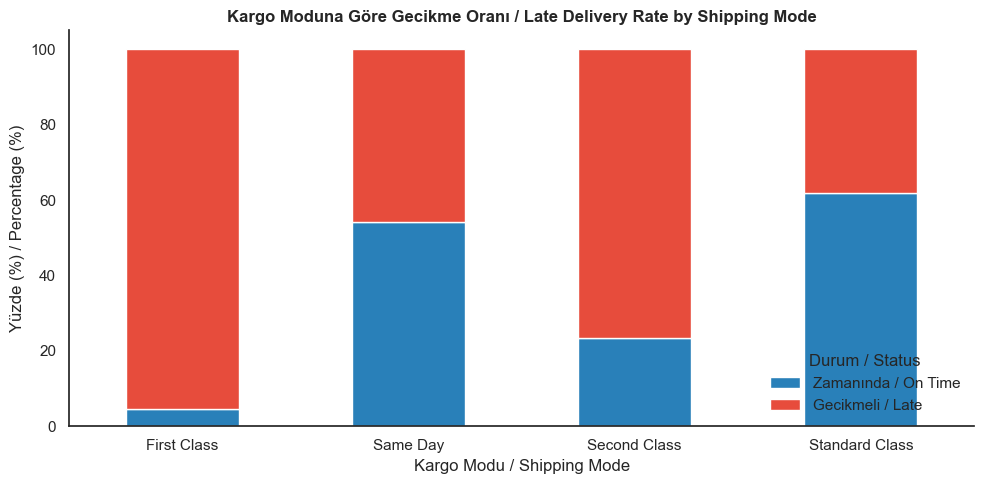

In [37]:
shipping_risk = pd.crosstab(df['shipping_mode'], df['late_delivery'], normalize='index') * 100

plt.figure(figsize=(10, 5))
shipping_risk.plot(kind='bar', stacked=True, color=[SECONDARY, ACCENT], figsize=(10, 5))
plt.title('Kargo Moduna Göre Gecikme Oranı / Late Delivery Rate by Shipping Mode')
plt.xlabel('Kargo Modu / Shipping Mode')
plt.ylabel('Yüzde (%) / Percentage (%)')
plt.legend(title='Durum / Status', labels=['Zamanında / On Time', 'Gecikmeli / Late'], 
           frameon=False, loc='lower right')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

> First Class kargo %95+ gecikme oranıyla açık ara en kötü performansı sergiliyor. Standard Class 
> ise ~%38 gecikme oranıyla en iyi sonucu veriyor. Kargo modu, gecikme tahmininde güçlü bir 
> özellik olma potansiyeli taşıyor.

> First Class shipping shows the worst performance with over 95% late delivery rate. 
> Standard Class performs best at ~38% late delivery. Shipping mode appears to be 
> a strong predictor for late delivery.

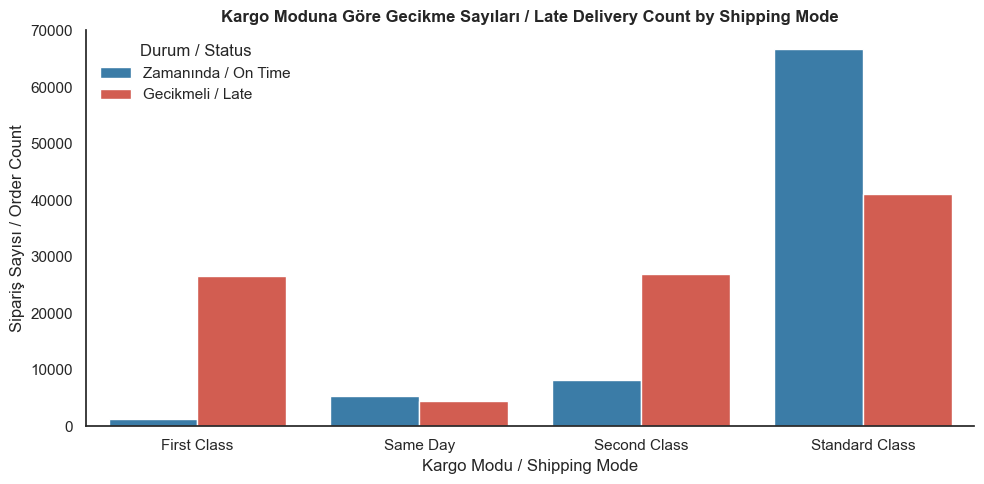

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='shipping_mode', hue='late_delivery', palette=[SECONDARY, ACCENT])
plt.title('Kargo Moduna Göre Gecikme Sayıları / Late Delivery Count by Shipping Mode')
plt.xlabel('Kargo Modu / Shipping Mode')
plt.ylabel('Sipariş Sayısı / Order Count')
plt.legend(title='Durum / Status', labels=['Zamanında / On Time', 'Gecikmeli / Late'], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

> Hacim bazında bakıldığında Standard Class hem en fazla zamanında hem de en fazla gecikmeli 
> siparişe sahip. Bu beklenen bir sonuç çünkü en çok kullanılan kargo modu o. 
> Önceki grafikteki oran bazlı analiz bu yüzden daha sağlıklı bir karşılaştırma sunuyor.

> In terms of volume, Standard Class has both the most on-time and the most late deliveries, 
> expected since it's the most used shipping mode. 
> The percentage-based analysis in the previous chart provides a more meaningful comparison.

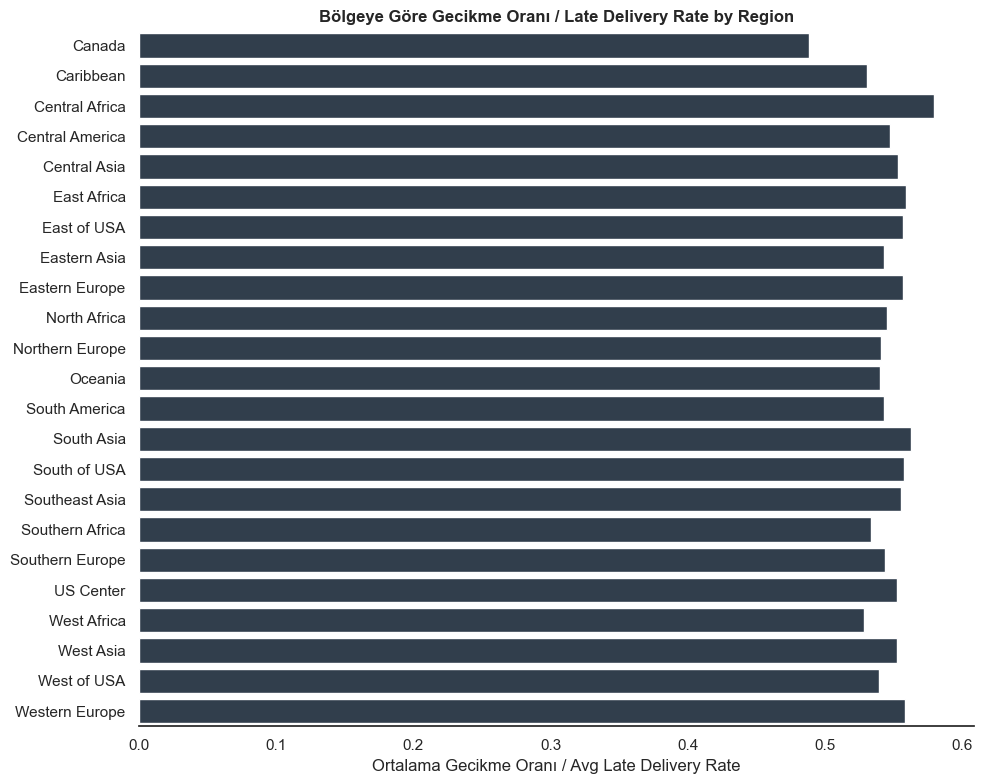

In [39]:
plt.figure(figsize=(10, 8))
region_risk = df.groupby('order_region')['late_delivery'].mean().sort_values(ascending=False)
sns.barplot(x=region_risk.values, y=region_risk.index, color=PRIMARY)
plt.title('Bölgeye Göre Gecikme Oranı / Late Delivery Rate by Region')
plt.xlabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> Tüm bölgeler %49-59 arasında yoğunlaşıyor; bölgeler arası fark oldukça dar. Central Africa 
> en yüksek gecikme oranına sahipken Canada en düşük

> All regions cluster between 49-59%, with relatively small differences across regions. 
> Central Africa has the highest late delivery rate while Canada has the lowest.

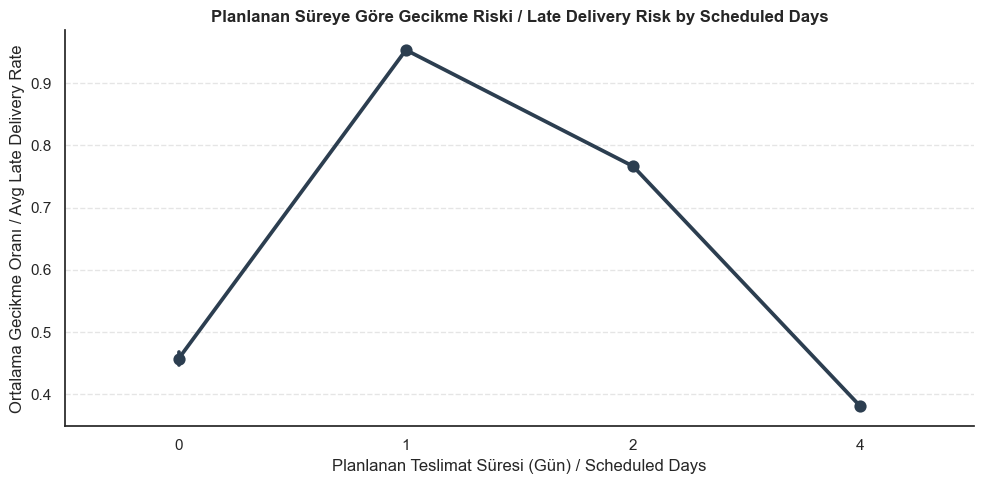

In [40]:
plt.figure(figsize=(10, 5))
sns.pointplot(x='scheduled_days', y='late_delivery', data=df, color=PRIMARY)
plt.title('Planlanan Süreye Göre Gecikme Riski / Late Delivery Risk by Scheduled Days')
plt.xlabel('Planlanan Teslimat Süresi (Gün) / Scheduled Days')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

> 1 günlük planlanan teslimat süresinde gecikme oranı %95'e çıkıyor, bu çarpıcı bir bulgu. 
> 4 günlük planlamada ise %38'e düşüyor. Planlanan süre ne kadar kısa olursa gecikme riski 
> o kadar yüksek; bu sütun modelde güçlü bir özellik olabilir.

> Orders with 1 scheduled day show a striking 95% late delivery rate. 
> At 4 scheduled days, this drops to 38%. Shorter planned delivery windows correlate with 
> higher late delivery risk, making this a potentially strong model feature.

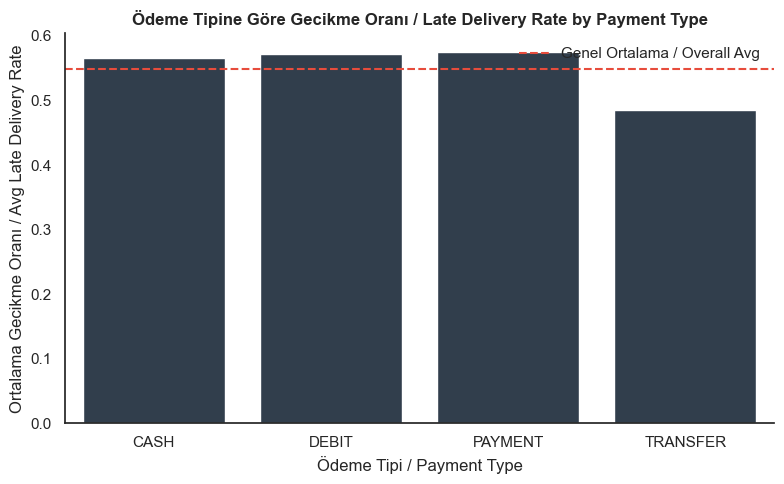

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(x='payment_type', y='late_delivery', data=df, color=PRIMARY, errorbar=None)
plt.axhline(df['late_delivery'].mean(), color=ACCENT, linestyle='--', label='Genel Ortalama / Overall Avg')
plt.title('Ödeme Tipine Göre Gecikme Oranı / Late Delivery Rate by Payment Type')
plt.xlabel('Ödeme Tipi / Payment Type')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

> TRANSFER ile yapılan ödemelerde gecikme oranı ~%48 ile genel ortalamanın belirgin şekilde 
> altında kalıyor. Diğer ödeme tipleri birbirine çok yakın ve ortalama civarında seyrediyor. 

> TRANSFER payments show a notably lower late delivery rate (~48%) compared to the overall average. 
> Other payment types cluster closely around the average.

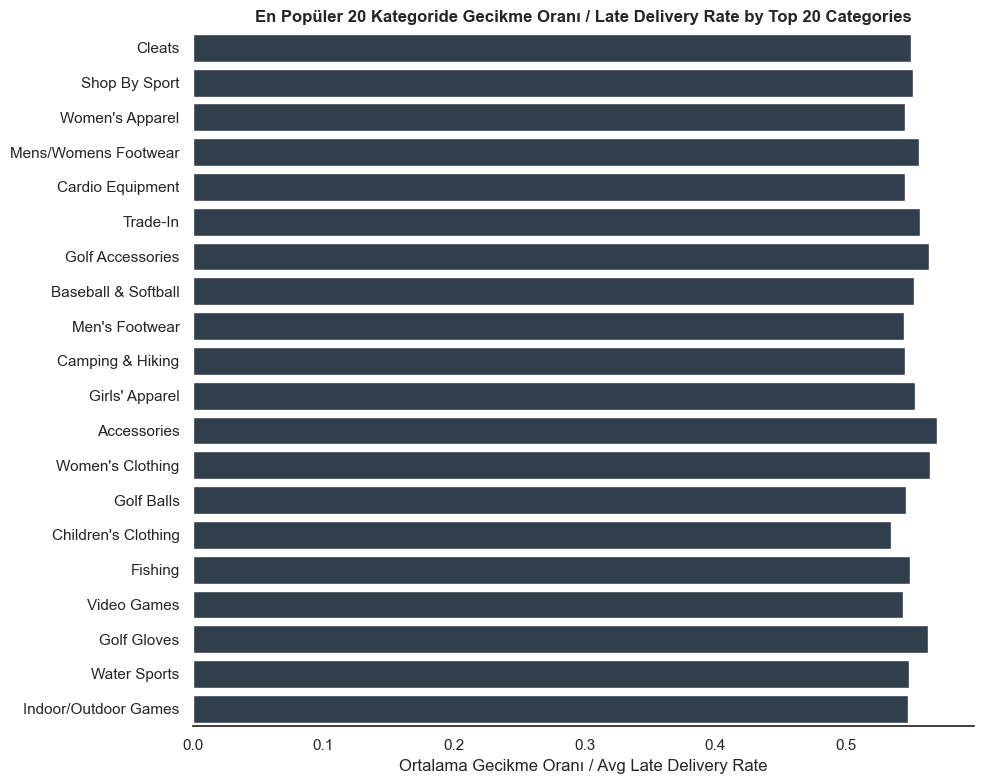

In [42]:
df_temp = df.copy()
df_temp['category_name'] = df_temp['category_name'].astype(str)

top_categories = df_temp['category_name'].value_counts().nlargest(20).index.tolist()
df_popular = df_temp[df_temp['category_name'].isin(top_categories)]

plt.figure(figsize=(10, 8))
sns.barplot(x='late_delivery', y='category_name', data=df_popular, color=PRIMARY, errorbar=None)
plt.title('En Popüler 20 Kategoride Gecikme Oranı / Late Delivery Rate by Top 20 Categories')
plt.xlabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> En popüler 20 kategori arasında gecikme oranları %50-58 arasında oldukça dar bir bantta 
> toplanıyor. Kategoriler arası fark minimal.

> Late delivery rates across the top 20 categories cluster tightly between 50-58%. 
> The differences between categories are minimal.

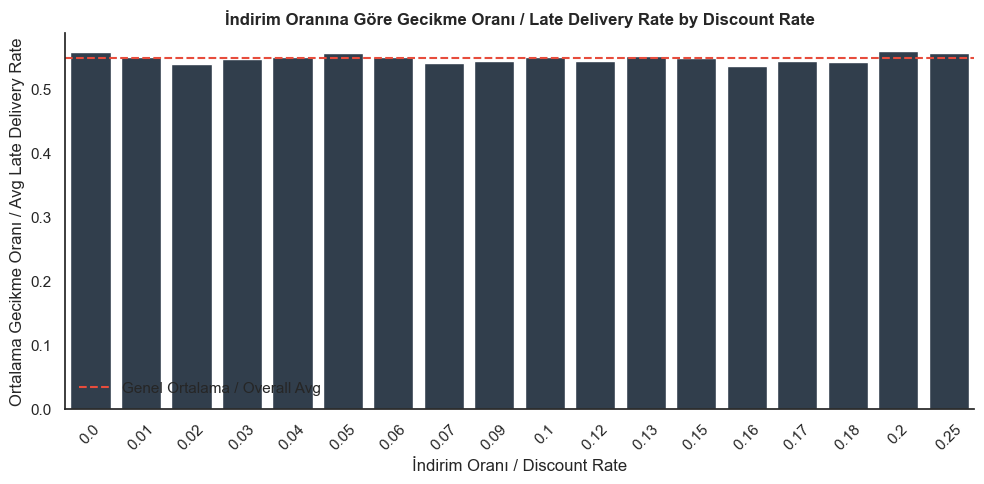

In [43]:
df['discount_rate'] = df['discount_rate'].round(2)

plt.figure(figsize=(10, 5))
sns.barplot(x='discount_rate', y='late_delivery', data=df, color=PRIMARY, errorbar=None)
plt.axhline(df['late_delivery'].mean(), color=ACCENT, linestyle='--', label='Genel Ortalama / Overall Avg')
plt.title('İndirim Oranına Göre Gecikme Oranı / Late Delivery Rate by Discount Rate')
plt.xlabel('İndirim Oranı / Discount Rate')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.xticks(rotation=45)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

> Tüm indirim oranlarında gecikme oranı genel ortalama etrafında sabit seyrediyor.

> The rate stays flat around the overall average across all discount levels.

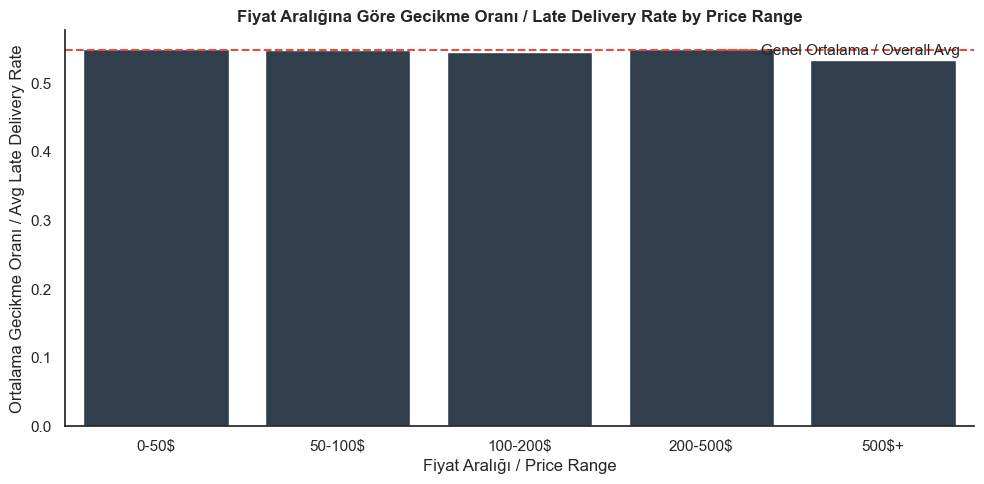

In [44]:
df['price_range'] = pd.cut(df['product_price'], bins=[0, 50, 100, 200, 500, 2000],
                            labels=['0-50$', '50-100$', '100-200$', '200-500$', '500$+'])
plt.figure(figsize=(10, 5))
sns.barplot(x='price_range', y='late_delivery', data=df, color=PRIMARY, errorbar=None)
plt.axhline(df['late_delivery'].mean(), color=ACCENT, linestyle='--', label='Genel Ortalama / Overall Avg')
plt.title('Fiyat Aralığına Göre Gecikme Oranı / Late Delivery Rate by Price Range')
plt.xlabel('Fiyat Aralığı / Price Range')
plt.ylabel('Ortalama Gecikme Oranı / Avg Late Delivery Rate')
plt.legend(frameon=False, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

> Ürün fiyat aralığı ile gecikme arasında ilişki zayıf. Ürün fiyatı gecikme tahmini için 
> zayıf bir özellik olarak değerlendirilebilir.

> Product price range shows a weak relationship with late delivery. Product price is likely a weak predictor 
> for late delivery.

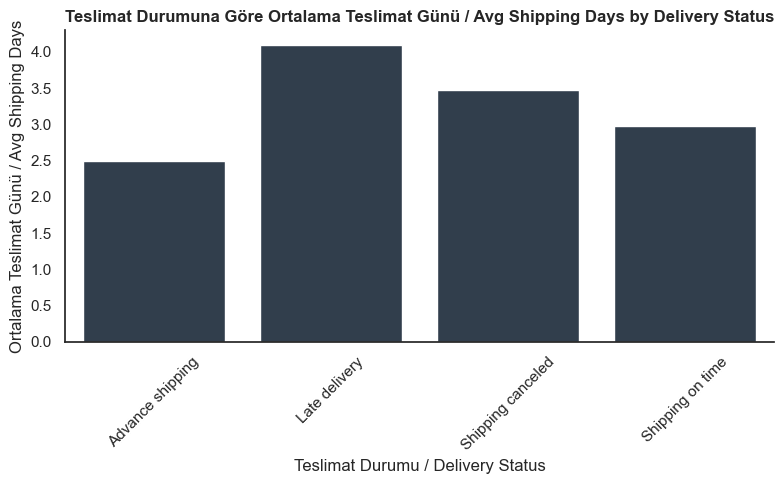

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(x='delivery_status', y='real_days', data=df, color=PRIMARY, errorbar=None)
plt.title('Teslimat Durumuna Göre Ortalama Teslimat Günü / Avg Shipping Days by Delivery Status')
plt.xlabel('Teslimat Durumu / Delivery Status')
plt.ylabel('Ortalama Teslimat Günü / Avg Shipping Days')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

> Gecikmeli teslimatların ortalama 4 günde tamamlandığı görülüyor; zamanında teslimatlar 
> ortalama 3, erken teslimatlar ise 2.5 günde tamamlanıyor. Gerçek teslimat süresi 
> gecikme durumunu doğrudan yansıtıyor. Bu sütun modelde güçlü bir özellik olabilir.

> Late deliveries average 4 days, on-time deliveries average 3 days, and advance shipments 
> average 2.5 days. Actual shipping days directly reflects delivery status.
> This feature may be a strong predictor in the model.

### 2.5. Satış & Kar Analizi
##### 2.5. Sales & Profit Analysis

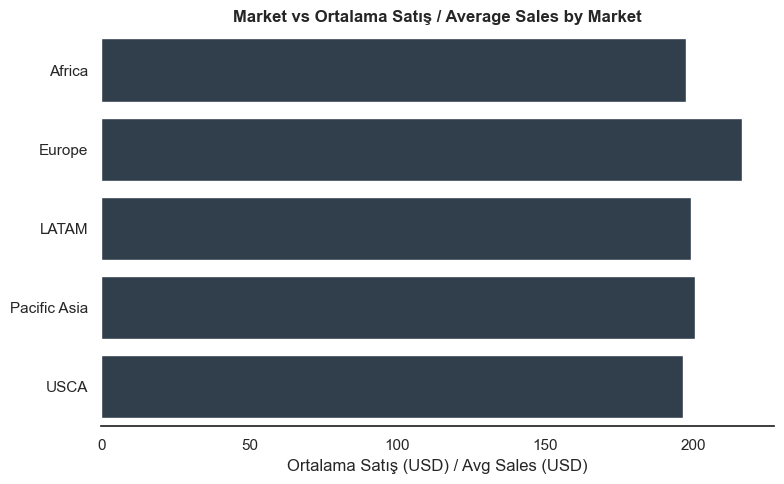

In [46]:
plt.figure(figsize=(8, 5))
market_sales = df.groupby('market')['sales'].mean().sort_values()
sns.barplot(x=market_sales.values, y=market_sales.index, color=PRIMARY)
plt.title('Market vs Ortalama Satış / Average Sales by Market')
plt.xlabel('Ortalama Satış (USD) / Avg Sales (USD)')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> Europe en yüksek ortalama satışa sahip market. Diğer tüm marketler birbirine çok yakın 
> ~200$ civarında seyrediyor. Marketler arası ortalama satış farkı oldukça dar.

> Europe leads in average sales per order. All other markets cluster closely around ~$200. 
> The difference in average sales across markets is relatively small.

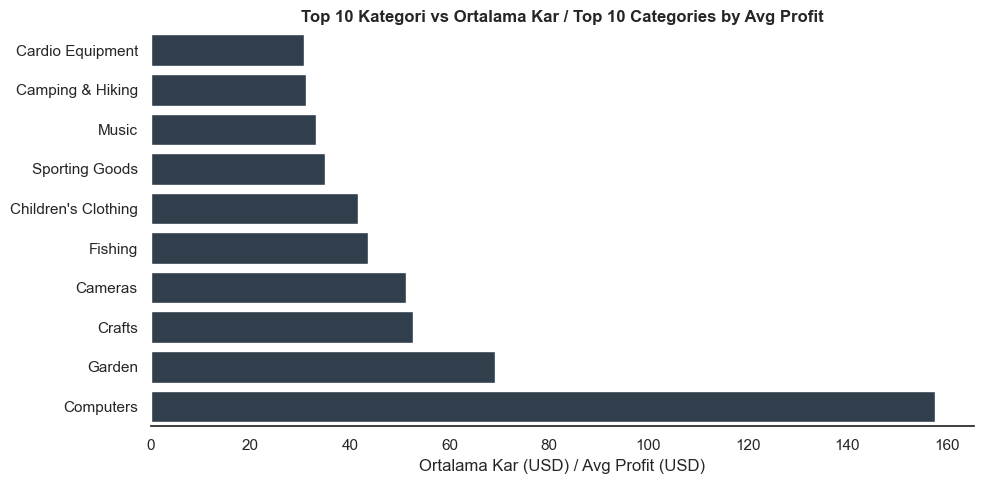

In [47]:
plt.figure(figsize=(10, 5))
cat_profit = df.groupby('category_name')['benefit_per_order'].mean().sort_values()
cat_profit.index = cat_profit.index.astype(str)
cat_profit = cat_profit.tail(10)
sns.barplot(x=cat_profit.values, y=cat_profit.index, color=PRIMARY)
plt.title('Top 10 Kategori vs Ortalama Kar / Top 10 Categories by Avg Profit')
plt.xlabel('Ortalama Kar (USD) / Avg Profit (USD)')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> Computers kategorisi ~160$ ortalama karla diğer kategorilerden açık ara önde. 
> Garden ve Crafts ikinci grubu oluştururken Cardio Equipment ve Camping & Hiking 
> en düşük kar marjlı kategoriler.

> Computers leads by a wide margin with ~$160 average profit per order. 
> Garden and Crafts form a second tier, while Cardio Equipment and Camping & Hiking 
> show the lowest average profit margins.

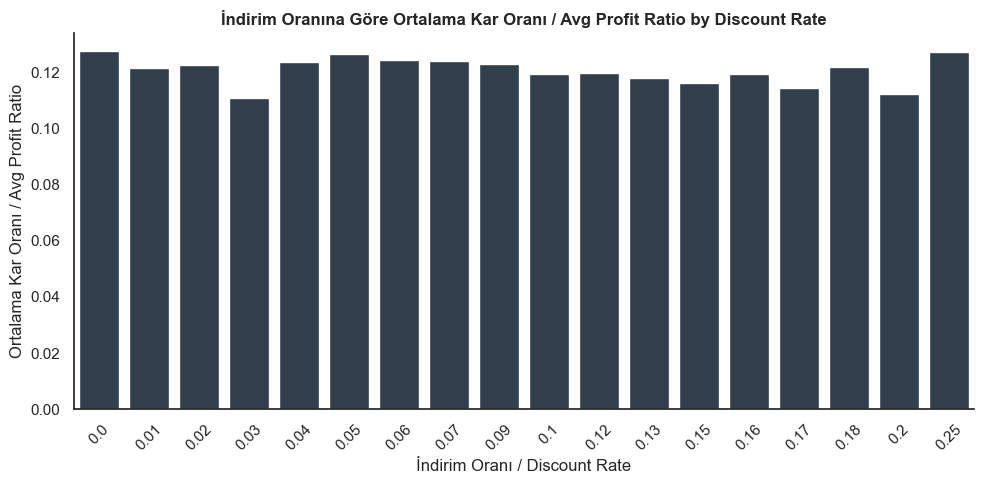

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(x='discount_rate', y='profit_ratio', data=df, color=PRIMARY, errorbar=None)
plt.title('İndirim Oranına Göre Ortalama Kar Oranı / Avg Profit Ratio by Discount Rate')
plt.xlabel('İndirim Oranı / Discount Rate')
plt.ylabel('Ortalama Kar Oranı / Avg Profit Ratio')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

> İndirim oranı ile kar oranı arasında neredeyse hiç ilişki yok, tüm indirim seviyelerinde 
> ortalama kar oranı ~0.12 civarında sabit kalıyor. İndirim artırmanın kar oranını 
> olumsuz etkilemediği görülüyor.

> There is almost no relationship between discount rate and profit ratio, average profit 
> ratio stays flat around ~0.12 across all discount levels. Increasing discounts does not 
> appear to negatively impact profit ratio.

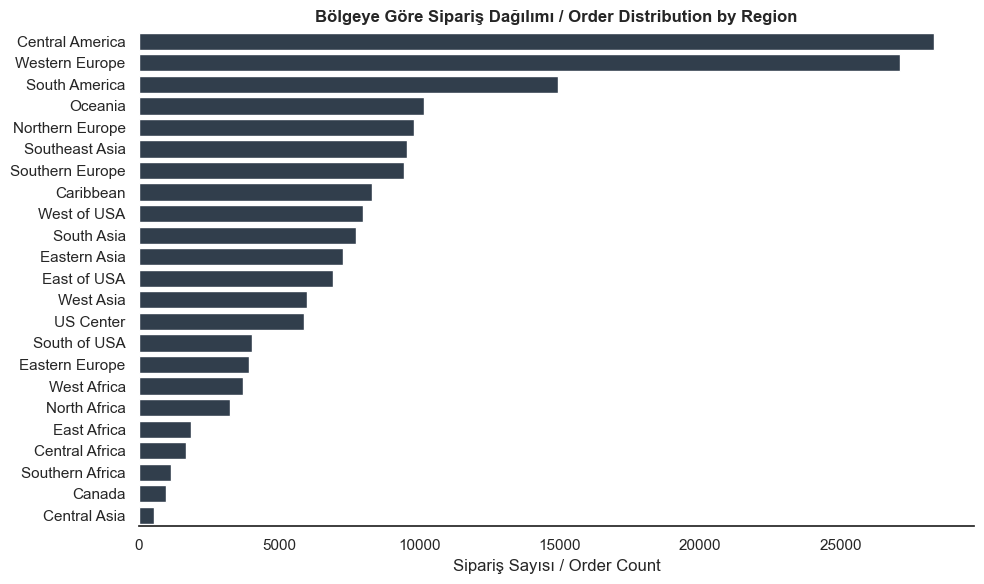

In [49]:
plt.figure(figsize=(10, 6))
region_counts = df['order_region'].value_counts()
sns.barplot(x=region_counts.values, y=region_counts.index.astype(str), color=PRIMARY)
plt.title('Bölgeye Göre Sipariş Dağılımı / Order Distribution by Region')
plt.xlabel('Sipariş Sayısı / Order Count')
plt.ylabel('')
sns.despine(left=True)
plt.tight_layout()
plt.show()

> Central America ve Western Europe sipariş hacminde açık ara önde, her biri ~28.000 sipariş 
> ile diğer bölgelerin iki katına yakın. Central Asia ve Canada en az sipariş alan bölgeler.

> Central America and Western Europe lead in order volume with ~28,000 orders each, nearly 
> double the next regions. Central Asia and Canada receive the fewest orders.

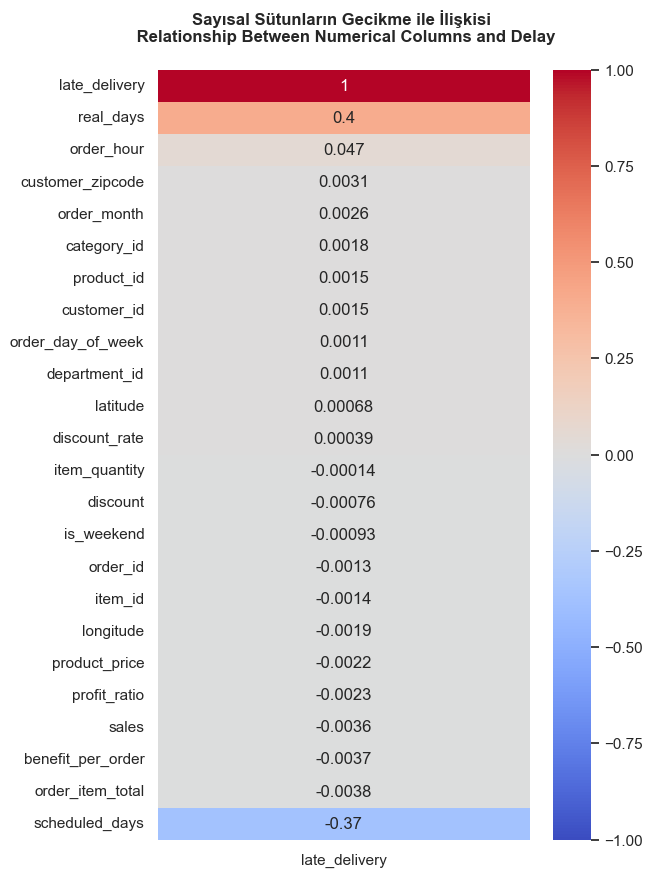

In [50]:
numeric_df = df.select_dtypes(include=['number'])

correlations = numeric_df.corr()['late_delivery'].sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Sayısal Sütunların Gecikme ile İlişkisi \n Relationship Between Numerical Columns and Delay", fontsize=12, weight='bold', pad=20)
plt.show()

> `real_days` (0.40) ve `scheduled_days` (-0.37) gecikme ile en güçlü korelasyona sahip 
> sütunlar. `order_hour` (0.047) ile zayıf da olsa bir ilişki var. Bu sonuç grafiklerdeki bulgularla örtüşüyor: 
> teslimat süresi bilgisi gecikme tahmini için en kritik özellik.

> `real_days` (0.40) and `scheduled_days` (-0.37) show the strongest correlation with 
> late delivery. `order_hour` shows a weak relationship (0.047). This aligns with earlier visualizations: shipping day information 
> is the most critical feature for predicting late delivery.